# This notebook is to test the exact bayesian optimization framework proposed

## 0 - Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel
from numpy.linalg import inv, eigvalsh
from math import erf, sqrt, exp, pi

## 1 - Define functions to estimate EI intervals

### 1.1 - Interval helpers

In [2]:
def split_intervals(intervals):
    """Split each [L,R] into [L,M] and [M,R]."""
    out = []
    for L, R in intervals:
        M = 0.5*(L+R)
        out.append((L, M))
        out.append((M, R))
    return out

def interval_midpoints(intervals):
    """Return midpoints as column vector suitable for sklearn (n,1)."""
    mids = [0.5*(L+R) for (L, R) in intervals]
    return np.array(mids, dtype=float).reshape(-1, 1)

### 1.2 - Interval utilities

In [3]:
def Phi(z: float) -> float:
    """Standard normal CDF."""
    return 0.5 * (1.0 + erf(z / sqrt(2.0)))

def phi(z: float) -> float:
    """Standard normal PDF."""
    return (1.0 / sqrt(2.0 * pi)) * exp(-0.5 * z * z)

### 1.3 - RBF Kernel Bounds

In [4]:
def rbf_K_interval(L: float, R: float, xi: float, sigma_f2: float, ell: float):
    """
    Compute [K_{i,min}, K_{i,max}] for k(x,xi)=sigma_f^2*exp(-(x-xi)^2/(2 ell^2)), x in [L,R].
    """
    # Bounds for D_i
    Dmin = min(abs(L - xi), abs(R - xi))
    Dmax = max(abs(L - xi), abs(R - xi))
    # S_i = D_i^2 / (2 ell^2)
    Smin = (Dmin ** 2) / (2.0 * ell ** 2)
    Smax = (Dmax ** 2) / (2.0 * ell ** 2)
    # E_i = exp(-S_i) is decreasing in S_i
    Emin = exp(-Smax)
    Emax = exp(-Smin)
    # K_i = sigma_f^2 * E_i
    Kmin = sigma_f2 * Emin
    Kmax = sigma_f2 * Emax
    return float(Kmin), float(Kmax)

### 1.4 - GP Posterior Mean Bounds

In [5]:
def gp_mu_interval_bounds(X, y, L, R, sigma_f2, ell, sigma_n2=0.0):
    """
    Compute [μ_lo, μ_hi] for μ(x)=k(x)^T α, α=(K+σ_n^2 I)^(-1) y, x in [L,R].
    """
    X = np.asarray(X, dtype=float).ravel()
    y = np.asarray(y, dtype=float).ravel()
    n = len(X)

    # Build K(X,X)
    D2 = (X[:, None] - X[None, :]) ** 2
    K = sigma_f2 * np.exp(- D2 / (2.0 * ell ** 2))

    # α = (K + σ_n^2 I)^(-1) y
    A = np.linalg.solve(K + sigma_n2 * np.eye(n), np.eye(n))   # (K+σ_n^2 I)^{-1}
    alpha = A @ y

    # Componentwise kernel intervals
    Kmins = np.empty(n, dtype=float)
    Kmaxs = np.empty(n, dtype=float)
    for i, xi in enumerate(X):
        Kmins[i], Kmaxs[i] = rbf_K_interval(L, R, xi, sigma_f2, ell)

    # μ bounds: sum of α_i * K_i with interval multiplication
    mu_lo = 0.0
    mu_hi = 0.0
    for a, kmin, kmax in zip(alpha, Kmins, Kmaxs):
        lo_i = min(a * kmin, a * kmax)
        hi_i = max(a * kmin, a * kmax)
        mu_lo += lo_i
        mu_hi += hi_i

    return float(mu_lo), float(mu_hi), A, Kmins, Kmaxs

### 1.5 - GP Posterior Standard Deviation Bounds

In [6]:
def gp_sigma_interval_bounds(A, Kmins, Kmaxs, sigma_f2):
    """
    Given A=(K+σ_n^2 I)^{-1} and per-component kernel intervals [Kmin_i,Kmax_i] (nonnegative),
    bound Q = k^T A k = sum_i A_ii k_i^2 + 2 sum_{i<j} A_ij k_i k_j,
    then σ^2 = σ_f^2 - Q, and finally σ ∈ [sqrt(max(0,σ^2_lo)), sqrt(max(0,σ^2_hi))].
    """
    A = np.asarray(A, dtype=float)
    n = A.shape[0]
    Kmins = np.asarray(Kmins, dtype=float)
    Kmaxs = np.asarray(Kmaxs, dtype=float)

    # Diagonal terms
    I_lo = 0.0
    I_hi = 0.0
    for i in range(n):
        aii = A[i, i]
        t1 = aii * (Kmins[i] ** 2)
        t2 = aii * (Kmaxs[i] ** 2)
        I_lo += min(t1, t2)
        I_hi += max(t1, t2)

    # Off-diagonal terms (i<j), with nonnegative intervals so [k_i*k_j] = [kmin_i*kmin_j, kmax_i*kmax_j]
    O_lo = 0.0
    O_hi = 0.0
    for i in range(n):
        ki_min, ki_max = Kmins[i], Kmaxs[i]
        for j in range(i + 1, n):
            aij = A[i, j]
            kj_min, kj_max = Kmins[j], Kmaxs[j]
            p_min = ki_min * kj_min
            p_max = ki_max * kj_max
            t1 = 2.0 * aij * p_min
            t2 = 2.0 * aij * p_max
            O_lo += min(t1, t2)
            O_hi += max(t1, t2)

    Q_min = I_lo + O_lo
    Q_max = I_hi + O_hi

    # σ^2 interval: [max(0, σ_f^2 - Q_max), max(0, σ_f^2 - Q_min)]
    sig2_lo = max(0.0, sigma_f2 - Q_max)
    sig2_hi = max(0.0, sigma_f2 - Q_min)

    # σ interval by monotonicity of sqrt
    sig_lo = sqrt(sig2_lo)
    sig_hi = sqrt(sig2_hi)
    return float(sig_lo), float(sig_hi), float(Q_min), float(Q_max)

### 1.6 - EI Bounds

In [7]:
def ei_interval_explicit(f_min, mu_bounds, sigma_bounds):
    """
    Explicit IA bounds for EI on an interval using:
      EI = N * Phi(Z) + σ * phi(Z),  with N=f_min - μ,  Z=N/σ.
    Inputs:
      f_min        : current best observed value
      mu_bounds    : (μ_lo, μ_hi)
      sigma_bounds : (σ_lo, σ_hi) with σ_lo >= 0
    Returns:
      (EI_lo, EI_hi)
    """
    mu_lo, mu_hi = float(mu_bounds[0]), float(mu_bounds[1])
    sig_lo, sig_hi = float(sigma_bounds[0]), float(sigma_bounds[1])

    # Interval for N = f_min - μ
    N_min = f_min - mu_hi
    N_max = f_min - mu_lo

    # If σ_lo == 0, use a safe enclosure: EI increases with σ (for fixed μ), so
    # lower bound at σ=0; upper bound at (μ=μ_lo, σ=σ_hi).
    if sig_lo == 0.0:
        EI_lo = max(0.0, N_min)  # EI(μ=μ_hi, σ=0) is a lower bound
        if sig_hi > 0.0:
            Z_hi = (f_min - mu_lo) / sig_hi
            EI_hi = (f_min - mu_lo) * Phi(Z_hi) + sig_hi * phi(Z_hi)
            # Ensure nonnegativity
            EI_hi = max(EI_hi, EI_lo)
        else:
            # σ_hi is also zero → EI is exactly max(0, N)
            EI_hi = max(0.0, N_max)
        return float(EI_lo), float(EI_hi)

    # Otherwise, proceed with explicit IA through Z, Phi, phi
    # J = 1/σ ∈ [1/σ_hi, 1/σ_lo]
    J_min = 1.0 / sig_hi
    J_max = 1.0 / sig_lo

    # Z = N * J, full interval product (four corners)
    S = [N_min * J_min, N_min * J_max, N_max * J_min, N_max * J_max]
    Z_min, Z_max = min(S), max(S)

    # Phi(Z) interval (monotone)
    F_min = Phi(Z_min)
    F_max = Phi(Z_max)

    # phi(Z) interval (unimodal, symmetric)
    P_candidates = [phi(Z_min), phi(Z_max)]
    if Z_min <= 0.0 <= Z_max:
        P_candidates.append(phi(0.0))
    P_min = min(P_candidates)
    P_max = max(P_candidates)

    # U = N * Phi(Z)
    U_candidates = [
        N_min * F_min, N_min * F_max,
        N_max * F_min, N_max * F_max
    ]
    U_min, U_max = min(U_candidates), max(U_candidates)

    # V = σ * phi(Z)
    V_candidates = [
        sig_lo * P_min, sig_lo * P_max,
        sig_hi * P_min, sig_hi * P_max
    ]
    V_min, V_max = min(V_candidates), max(V_candidates)

    # EI = U + V (interval addition)
    return float(U_min + V_min), float(U_max + V_max)

### 1.7 - One-call Wrapper

In [8]:
def ei_bounds_on_interval(L, R, X, y, f_min, sigma_f2, ell, sigma_n2=0.0):
    """
    Compute EI interval [EI_lo, EI_hi] on x in [L,R], following the LaTeX sections:
      1) kernel intervals -> 2) μ interval -> 3) σ interval -> 4) EI explicit IA
    Returns:
      dict with μ_bounds, σ_bounds, Q_bounds, EI_bounds
    """
    mu_lo, mu_hi, A, Kmins, Kmaxs = gp_mu_interval_bounds(
        X, y, L, R, sigma_f2, ell, sigma_n2
    )
    sig_lo, sig_hi, Q_min, Q_max = gp_sigma_interval_bounds(
        A, Kmins, Kmaxs, sigma_f2
    )
    EI_lo, EI_hi = ei_interval_explicit(
        f_min, (mu_lo, mu_hi), (sig_lo, sig_hi)
    )
    return {
        "mu_bounds": (mu_lo, mu_hi),
        "sigma_bounds": (sig_lo, sig_hi),
        "Q_bounds": (Q_min, Q_max),
        "EI_bounds": (EI_lo, EI_hi),
    }

## 2 - Toy function to minimize

In [9]:
def f(x):
    return (x - 2)**2 + np.sin(5*x)

## 3 - EI Function

In [10]:
def expected_improvement(X, gp, y_min):
    mu, sigma = gp.predict(X, return_std=True)
    sigma = sigma.reshape(-1,1)
    mu = mu.reshape(-1,1)
    with np.errstate(divide='warn'):
        Z = (y_min - mu) / sigma # to minimize
        ei = (y_min - mu) * norm.cdf(Z) + sigma * norm.pdf(Z) # to minimize
        ei[sigma==0.0] = 0.0
    return ei.ravel()

## 4 - Define domain

In [11]:
a, b = 0.0, 4.0
intervals0 = [(a,b)]

## 5 - Iteration 0

### 5.1 - Sample at center

In [12]:
#x_c = 0.5*(a+b)
X = interval_midpoints(intervals0)
y = f(X)

### 5.2 - Build GP

In [13]:
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=0.5, length_scale_bounds=(1e-2, 1e2))
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, normalize_y=True)
gp.fit(X, y)

c:\Users\juan.florez\tamubo\venvs\venv313\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


,kernel,1**2 * RBF(length_scale=0.5)
,alpha,1e-06
,optimizer,'fmin_l_bfgs_b'
,n_restarts_optimizer,0
,normalize_y,True
,copy_X_train,True
,n_targets,None
,random_state,None
,kernel__k1,1**2
,kernel__k2,RBF(length_scale=0.5)
,kernel__k1__constant_value,1.0


### 5.3 - Plot

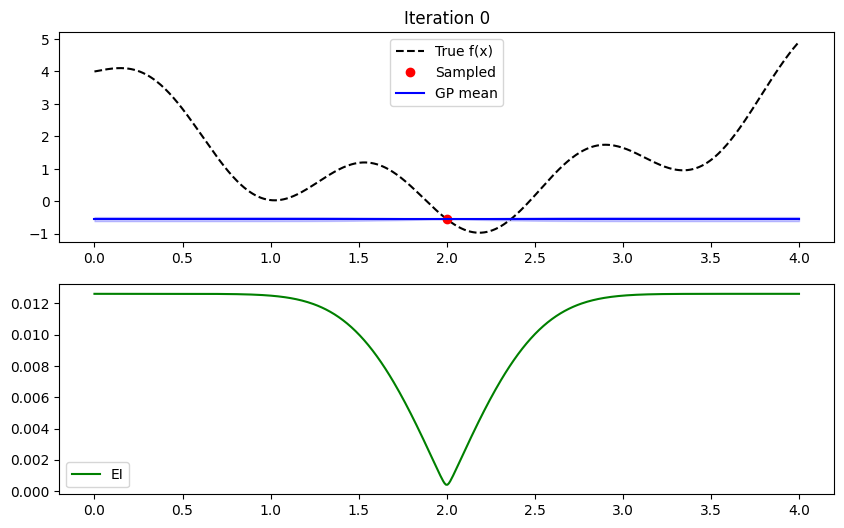

In [14]:
xx = np.linspace(a, b, 500).reshape(-1,1)
mu, sigma = gp.predict(xx, return_std=True)
ei = expected_improvement(xx, gp, np.min(y))

plt.figure(figsize=(10,6))
plt.subplot(2,1,1)
plt.plot(xx, f(xx), 'k--', label="True f(x)")
plt.plot(X, y, 'ro', label="Sampled")
plt.plot(xx, mu, 'b', label="GP mean")
plt.fill_between(xx.ravel(), mu-1.96*sigma, mu+1.96*sigma, alpha=0.2, color='b')
plt.legend(); plt.title("Iteration 0")

plt.subplot(2,1,2)
plt.plot(xx, ei, 'g', label="EI")
plt.legend()
plt.show()

### 5.4 - Show EI interval estimation in 2 subdomains

In [ ]:
intervals1 = split_intervals(intervals0)
for L,R in intervals1:
    f_min = float(y.min())
#    ei_min, ei_max = ei_interval_on_subdomain(gp, L, R)
#    print(f"Interval [{L:.2f}, {R:.2f}]: EI in [{ei_min:.6f}, {ei_max:.6f}]")
intervals1

[(0.0, 2.0), (2.0, 4.0)]

In [35]:
gp.kernel_.k1.theta

array([-6.90775528])

## 6 - Iteration 1

### 6.1 - Sample function at the midpoint of the feasible subdomains

In [16]:
X_new = interval_midpoints(intervals1)
y_new = f(X_new)

X = np.vstack([X, X_new])
y = np.vstack([y, y_new])

### 6.2 - Build GP

In [17]:
gp.fit(X, y)

,kernel,1**2 * RBF(length_scale=0.5)
,alpha,1e-06
,optimizer,'fmin_l_bfgs_b'
,n_restarts_optimizer,0
,normalize_y,True
,copy_X_train,True
,n_targets,None
,random_state,None
,kernel__k1,1**2
,kernel__k2,RBF(length_scale=0.5)
,kernel__k1__constant_value,1.0


### 6.3 - Plot

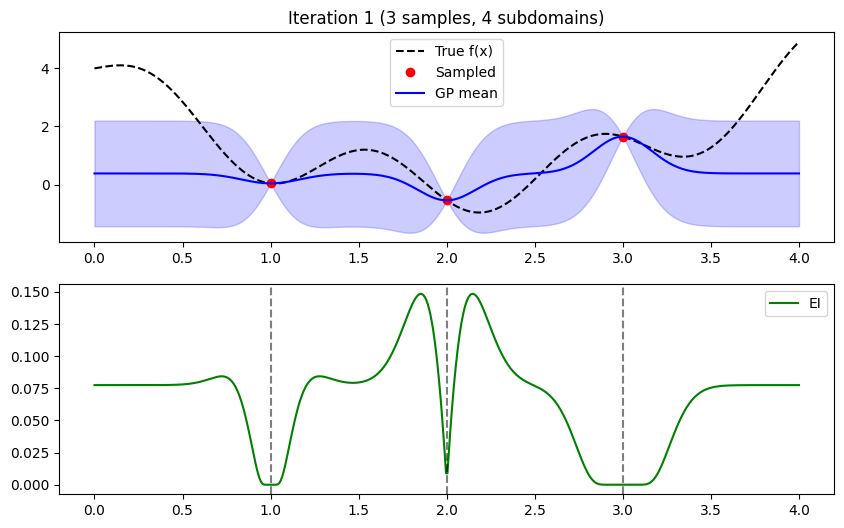

In [26]:
mu, sigma = gp.predict(xx, return_std=True)
ei = expected_improvement(xx, gp, np.min(y))

plt.figure(figsize=(10,6))
plt.subplot(2,1,1)
plt.plot(xx, f(xx), 'k--', label="True f(x)")
plt.plot(X, y, 'ro', label="Sampled")
plt.plot(xx, mu, 'b', label="GP mean")
plt.fill_between(xx.ravel(), mu-1.96*sigma, mu+1.96*sigma, alpha=0.2, color='b')
plt.legend(); plt.title("Iteration 1 (3 samples, 4 subdomains)")

plt.subplot(2,1,2)
plt.plot(xx, ei, 'g', label="EI")
for xvline in X.ravel():
    plt.axvline(xvline, color='k', ls='--', alpha=0.5) # subdomain split markers
#plt.axvline((a+x_c)/2, color='k', ls='--', alpha=0.5) # subdomain split markers
#plt.axvline((x_c+b)/2, color='k', ls='--', alpha=0.5)
#plt.axvline(x_c, color='k', ls=':')
plt.legend()
plt.show()

### 6.4 - Show EI interval estimation in 4 subdomains

In [27]:
intervals2 = split_intervals(intervals1)
for L,R in intervals2:
    ei_min, ei_max = ei_interval_on_subdomain(gp, L, R)
    print(f"Interval [{L:.2f}, {R:.2f}]: EI in [{ei_min:.6f}, {ei_max:.6f}]")

Interval [0.00, 1.00]: EI in [0.000000, 0.160426]
Interval [1.00, 2.00]: EI in [0.000000, 0.881473]
Interval [2.00, 3.00]: EI in [0.000000, 0.398945]
Interval [3.00, 4.00]: EI in [0.000000, 0.038228]


## 7 - Iteration 2

### 7.1 - Sample point at the midpoint of the feasible subdomains

In [28]:
X_new = interval_midpoints(intervals2)
y_new = f(X_new)

X = np.vstack([X, X_new])
y = np.vstack([y, y_new])

### 7.2 - Build GP

In [29]:
gp.fit(X, y)

,kernel,1**2 * RBF(length_scale=0.5)
,alpha,1e-06
,optimizer,'fmin_l_bfgs_b'
,n_restarts_optimizer,0
,normalize_y,True
,copy_X_train,True
,n_targets,None
,random_state,None
,kernel__k1,1**2
,kernel__k2,RBF(length_scale=0.5)
,kernel__k1__constant_value,1.0


### 7.3 - Plot

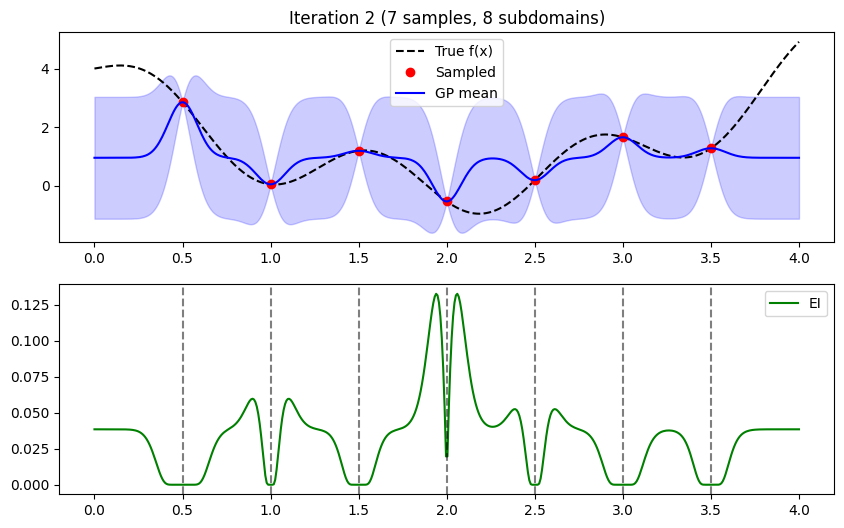

In [30]:
mu, sigma = gp.predict(xx, return_std=True)
ei = expected_improvement(xx, gp, np.min(y))

plt.figure(figsize=(10,6))
plt.subplot(2,1,1)
plt.plot(xx, f(xx), 'k--', label="True f(x)")
plt.plot(X, y, 'ro', label="Sampled")
plt.plot(xx, mu, 'b', label="GP mean")
plt.fill_between(xx.ravel(), mu-1.96*sigma, mu+1.96*sigma, alpha=0.2, color='b')
plt.legend(); plt.title("Iteration 2 (7 samples, 8 subdomains)")

plt.subplot(2,1,2)
plt.plot(xx, ei, 'g', label="EI")
for xvline in X.ravel():
    plt.axvline(xvline, color='k', ls='--', alpha=0.5) # subdomain split markers
#plt.axvline((a+x_c)/2, color='k', ls='--', alpha=0.5) # subdomain split markers
#plt.axvline((x_c+b)/2, color='k', ls='--', alpha=0.5)
#plt.axvline(x_c, color='k', ls=':')
plt.legend()
plt.show()

### 7.4 - Show EI interval estimation in 8 subdomains

In [31]:
intervals3 = split_intervals(intervals2)
for L,R in intervals3:
    ei_min, ei_max = ei_interval_on_subdomain(gp, L, R)
    print(f"Interval [{L:.2f}, {R:.2f}]: EI in [{ei_min:.6f}, {ei_max:.6f}]")

Interval [0.00, 0.50]: EI in [0.000000, 0.003123]
Interval [0.50, 1.00]: EI in [0.000000, 0.182602]
Interval [1.00, 1.50]: EI in [0.000000, 0.491420]
Interval [1.50, 2.00]: EI in [0.000000, 0.860958]
Interval [2.00, 2.50]: EI in [0.000000, 1.688717]
Interval [2.50, 3.00]: EI in [0.000000, 0.231721]
Interval [3.00, 3.50]: EI in [0.000000, 0.034861]
Interval [3.50, 4.00]: EI in [0.000000, 0.017782]


## 8. Test intervals

In [33]:
gp

,kernel,1**2 * RBF(length_scale=0.5)
,alpha,1e-06
,optimizer,'fmin_l_bfgs_b'
,n_restarts_optimizer,0
,normalize_y,True
,copy_X_train,True
,n_targets,None
,random_state,None
,kernel__k1,1**2
,kernel__k2,RBF(length_scale=0.5)
,kernel__k1__constant_value,1.0
